In [2]:
import pandas as pd

df_auth = pd.read_json("metrics(auth).json", lines=True)
df_gateway = pd.read_json("metrics(gateway).json", lines=True)
df_gateway

,type,data,metric
0,Metric,"{'name': 'http_reqs', 'type': 'counter', 'cont...",http_reqs
1,Point,"{'time': '2026-04-10T08:08:47.2276432+02:00', ...",http_reqs
2,Metric,"{'name': 'http_req_duration', 'type': 'trend',...",http_req_duration
3,Point,"{'time': '2026-04-10T08:08:47.2276432+02:00', ...",http_req_duration
4,Metric,"{'name': 'http_req_blocked', 'type': 'trend', ...",http_req_blocked
...,...,...,...
337905,Point,"{'time': '2026-04-10T08:10:49.0599871+02:00', ...",checks
337906,Point,"{'time': '2026-04-10T08:10:49.0599871+02:00', ...",data_sent
337907,Point,"{'time': '2026-04-10T08:10:49.0599871+02:00', ...",data_received
337908,Point,"{'time': '2026-04-10T08:10:49.0599871+02:00', ...",iteration_duration


In [3]:
df_auth.describe


<bound method NDFrame.describe of            type                                               data  \
0        Metric  {'name': 'http_reqs', 'type': 'counter', 'cont...   
1         Point  {'time': '2026-04-10T07:51:47.4948998+02:00', ...   
2        Metric  {'name': 'http_req_duration', 'type': 'trend',...   
3         Point  {'time': '2026-04-10T07:51:47.4948998+02:00', ...   
4        Metric  {'name': 'http_req_blocked', 'type': 'trend', ...   
...         ...                                                ...   
1807931   Point  {'time': '2026-04-10T07:53:47.3713436+02:00', ...   
1807932   Point  {'time': '2026-04-10T07:53:47.3713436+02:00', ...   
1807933   Point  {'time': '2026-04-10T07:53:47.3713436+02:00', ...   
1807934   Point  {'time': '2026-04-10T07:53:47.3713436+02:00', ...   
1807935   Point  {'time': '2026-04-10T07:53:47.3713436+02:00', ...   

                     metric  
0                 http_reqs  
1                 http_reqs  
2         http_req_duration  
3    

In [2]:
df_gateway.columns

Index(['type', 'data', 'metric'], dtype='object')

In [4]:
gateway_points = df_gateway[df_gateway["type"] == "Point"].copy()
auth_points = df_auth[df_auth["type"] == "Point"].copy()


In [5]:
expanded_auth = pd.json_normalize(auth_points["data"])
expanded_gateway = pd.json_normalize(gateway_points["data"])

In [6]:
expanded_auth["metric"] = auth_points["metric"].values
expanded_gateway["metric"] = gateway_points["metric"].values

In [7]:
expanded_gateway.describe


<bound method NDFrame.describe of                                      time       value tags.expected_response  \
0       2026-04-10T08:08:47.2276432+02:00      1.0000                   true   
1       2026-04-10T08:08:47.2276432+02:00     44.5045                   true   
2       2026-04-10T08:08:47.2276432+02:00      1.0128                   true   
3       2026-04-10T08:08:47.2276432+02:00      1.0128                   true   
4       2026-04-10T08:08:47.2276432+02:00      0.0000                   true   
...                                   ...         ...                    ...   
337889  2026-04-10T08:10:49.0599871+02:00      0.0000                    NaN   
337890  2026-04-10T08:10:49.0599871+02:00     89.0000                    NaN   
337891  2026-04-10T08:10:49.0599871+02:00      0.0000                    NaN   
337892  2026-04-10T08:10:49.0599871+02:00  30007.6591                    NaN   
337893  2026-04-10T08:10:49.0599871+02:00      1.0000                    NaN   

     

In [8]:
auth_df = expanded_auth[expanded_auth["metric"] == "http_req_duration"].copy()
gateway_df = expanded_gateway[expanded_gateway["metric"] == "http_req_duration"].copy()

In [11]:
gateway_df["value"].describe()


count    24118.000000
mean       198.700236
std       2271.027430
min          1.712200
25%          8.000575
50%         14.225500
75%         24.314800
max      30010.638900
Name: value, dtype: float64

In [12]:
auth_df.describe()

,value
count,129120.000000
mean,30.989120
std,20.931218
min,0.510700
25%,16.814675
50%,27.821400
75%,40.588700
max,344.145400


In [9]:
gateway_df = gateway_df.dropna(axis=1, how="all").copy()
auth_df = auth_df.dropna(axis=1, how="all").copy()

In [10]:
auth_df["time"] = pd.to_datetime(auth_df["time"])
auth_df = auth_df.sort_values("time")

gateway_df["time"] = pd.to_datetime(gateway_df["time"])
gateway_df = gateway_df.sort_values("time")

# Convert to seconds relative to first timestamp
auth_df["time_sec"] = (auth_df["time"] - auth_df["time"].min()).dt.total_seconds()
gateway_df["time_sec"] = (gateway_df["time"] - gateway_df["time"].min()).dt.total_seconds()

In [11]:
gateway_df["time_sec"]

1           0.000000
15          0.008921
29          0.013443
43          0.023631
57          0.028387
             ...    
337843    121.830829
337852    121.830829
337821    121.830829
337834    121.830829
337861    121.830829
Name: time_sec, Length: 24118, dtype: float64

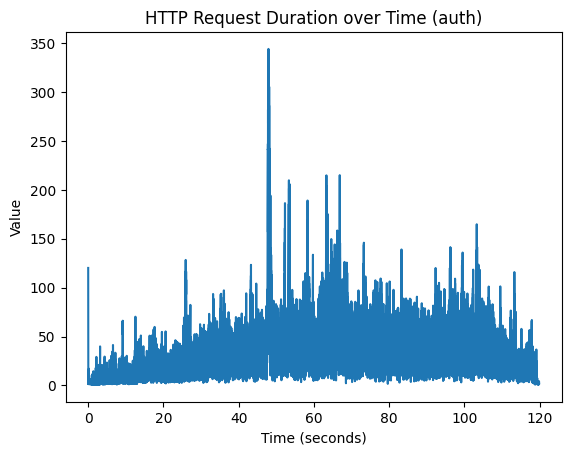

In [12]:
import matplotlib.pyplot as plt

plt.plot(auth_df[auth_df["tags.test"] == "transport_ping"].time_sec, auth_df[auth_df["tags.test"] == "transport_ping"].value, label="auth")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time (auth)")
plt.show()

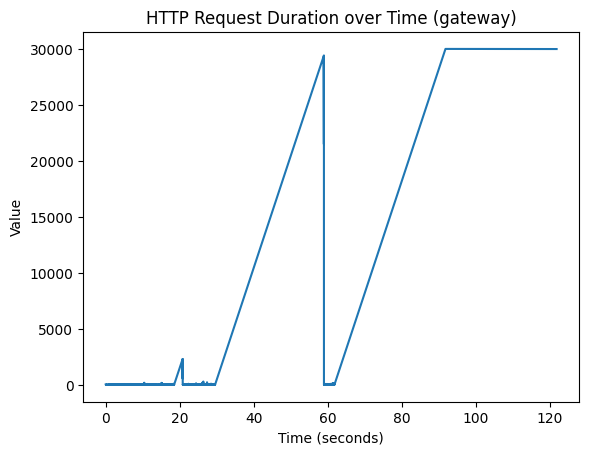

In [13]:
plt.plot(gateway_df[gateway_df["tags.test"] == "transport_ping"].time_sec, gateway_df[gateway_df["tags.test"] == "transport_ping"].value, label="gateway")
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time (gateway)")
plt.show()

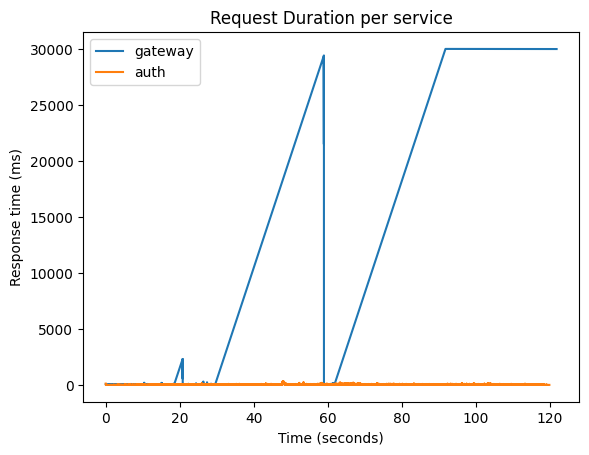

In [14]:
plt.plot(gateway_df[gateway_df["tags.test"] == "transport_ping"].time_sec, gateway_df[gateway_df["tags.test"] == "transport_ping"].value, label="gateway")
plt.plot(auth_df[auth_df["tags.test"] == "transport_ping"].time_sec, auth_df[auth_df["tags.test"] == "transport_ping"].value, label="auth")
plt.xlabel("Time (seconds)")
plt.ylabel("Response time (ms)")
plt.legend()
plt.title("Request Duration per service")
plt.show()